<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Requirements:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 
Compatible with data_handling.py and fit_FMR_class.py (currently only Generalizing-complex-fits branch)
<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
V Original
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
"> 

In [2]:
import h5py
import numpy as np 
import sys

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA_analysis\VNA_data\VNA_analysis")
from data_handling import Analysis_FMR_HSweep, FitStore
import fit_FMR_class as models
import complex_fits as fits
import fitting_functions as funcs
import resonance_functions as res_func
import calculators as calcs

import ipywidgets as widgets
from ipywidgets import interact

from scipy.optimize import curve_fit

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Files Information:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
Fill in the information about the files to be analyzed. Create a class entity for each file with Analysis_PSWS()

In [4]:
#Folders where file are. Keep the r to use raw string in Windows.
address1 = Path(r"C:\Users\jose1\OneDrive\PostDoc_FZU\DATA\joseS\20260528_Co_a\inP_a_along310\3dBm\FMR_2026_08_06")

In [5]:
example_file_name_1 = "2026_08_06_FMR_Hsweep_0p285Ato5p285Ain201_3dBm_11p722GHz_14_34.h5.ma8"

In [6]:
sample = "20260528_Co_a_inP_a_along310"

In [7]:
geometry = "inP" #either "inP" or "outP"

In [8]:
vna_ref_subtracted = True #Was a reference already subtracted during measurements?

In [9]:
ansy1 = Analysis_FMR_HSweep(address1, example_file_name_1, sample, "FZU_FMR_HSweep", geometry, vna_ref_subtracted)

In [10]:
store_in_origin = True #True if you wnat to store fit results in orignal file, otherwise another h5f file is created in the same directory

In [11]:
newfile_name =  (sample + f"_LorentzFits_results_{ansy1.power}dBm")
newfile_name = newfile_name.replace(".","p").replace("-","m")
newfile_name = newfile_name + ".h5"
newFile = address1/newfile_name
fits_storage = FitStore (newFile, val_type= 'freq', group="Lorentzian fitting")

<div style="
font-size:22px;
font-weight:600;
color:#1F2933;
">
Data visualization:
<div style="
font-size:18px;
font-weight:600;
color:#1F2933;
">
plot_dL_slider() allows one to preview the data for each field to select the best reference subraction.

In [13]:
#ansy1.plot_dij_slider('d_S', n_0=5)

In [14]:
#Frequencies available in the data set, we can use them to find their corresponding data

In [15]:
print(ansy1.freqs)

[ 3.688  3.719  6.417  6.528  8.565 10.257 11.722 13.015 14.181 15.249
 16.247 17.196 18.118 19.023 19.917 20.802 21.674 22.532 23.371 24.185
 24.973 25.737 26.481 27.209 27.928 28.651 29.384 30.138 30.918 31.727
 32.569 33.441 34.337 35.247 36.165 37.077 37.972 38.837 39.667 40.454]


In [16]:
float(ansy1.freqs[9])

15.249

In [17]:
# Example of a single fit

{'Ar': -1.9041924005609834e-06, 'Ai': 1.1940337123223524e-06, 'Ho': 0.18, 'dH': 0.00020226947764559109, 're0': 0.0038, 'im0': -0.003}
Initial simplex fit


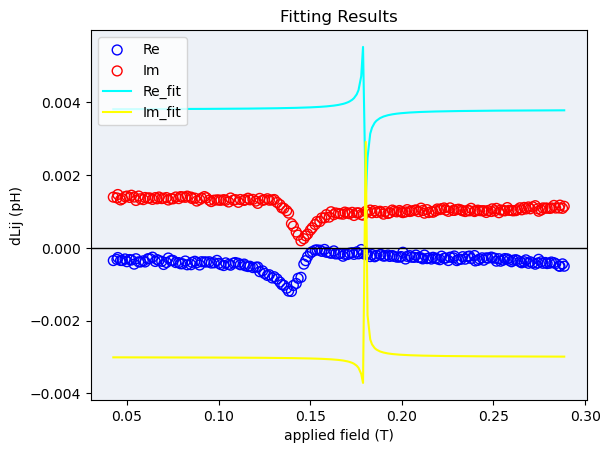

Final fit and results


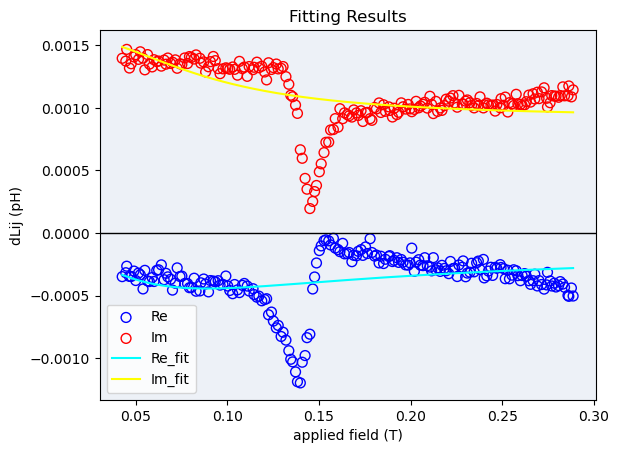


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.889e-05      1.471e-05         U        No
Ai                    -1.220e-06      1.483e-05         U        No
Ho                        0.0150              -         T       Yes
dH                        0.0758         0.0279         T        No
re0                   -1.127e-04      7.382e-05         U        No
im0                    9.232e-04      3.256e-05         U        No
----------------------------------------------------------------------
The phase is: 181.42946462862955


In [31]:
ini_vals = [0.05, 0.05, 0.038, 0.0001, 0, 0] #Ar, Ai, Ho, dH, re0, im0
freq = 13.015
f_index = int(np.where(ansy1.freqs == freq)[0][0])
H_center = 0.18

H_min, H_max = H_center-0.5, H_center+0.5 #T
h_array = ansy1.get_field(freq)

y_array_re, y_array_im = ansy1.d_S("21R", freq), ansy1.d_S("21I", freq)

model = models.ComplexLorentzian_field()
fitter = fits.ComplexFitter( ini_vals, H_min, H_max,
    h_array, y_array_re , y_array_im, model)
fitter.fix(Ho=H_center, re0=0.0038, im0=-0.003) # Parameters to be fixed, empty otherwise
opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'
print(opt_p0)
print("Initial simplex fit")
fitter.plot_fit_simplex_wpm()

new_p0 = np.array(list(opt_p0.values()), dtype=float)
fitter.update_p0(new_p0)

fitter.fix(Ho=0.015) #,re0=0.0038, im0=-0.003)

params, cov = fitter.fit(simplex_b=False)
print("Final fit and results")
fitter.plot_fit()
fitter.summary()
print(f"The phase is: {model.phase_deg(**params)}")

In [ ]:
#If we are happy with the fit, we can save it.

In [ ]:
fit_dict = fitter.export_fit_dict()

fits_storage.save(index=f_index, val=float(ansy1.freqs[f_index]), fit_dict=fit_dict)

In [ ]:
fit_dict["params"]["Ho"]

In [ ]:
# Automatic fitting of entire spectra. Enter the estimated parameters for the Kittel model guiding the automatic fitting.

Index= 0, freq.=3.688 GHz, Guide field.=0.015818069554652925


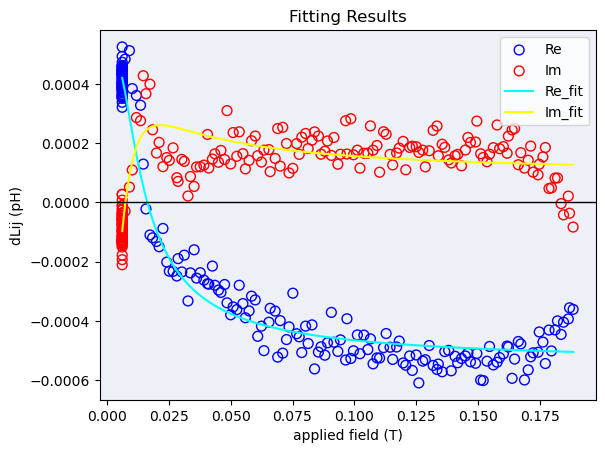


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.478e-06      7.181e-07         U        No
Ai                     7.328e-06      7.181e-07         U        No
Ho                     1.077e-17      6.758e-04         T        No
dH                        0.0088      6.758e-04         T        No
re0                   -5.459e-04      1.030e-05         U        No
im0                    8.974e-05      1.030e-05         U        No
----------------------------------------------------------------------
Index= 1, freq.=3.719 GHz, Guide field.=0.015999383808528722


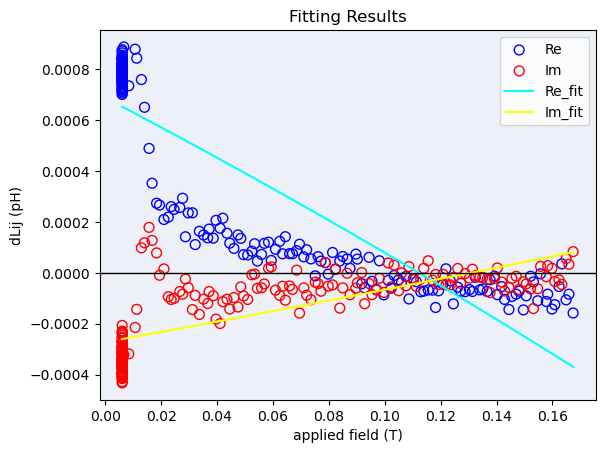


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.0213         0.0711         U        No
Ai                       -0.0125         0.0711         U        No
Ho                        2.0000         2.7842         T        No
dH                        0.2000         2.7842         T        No
re0                       0.0118         0.0184         U        No
im0                      -0.0054         0.0184         U        No
----------------------------------------------------------------------
Index= 2, freq.=6.417 GHz, Guide field.=0.03729402403194304


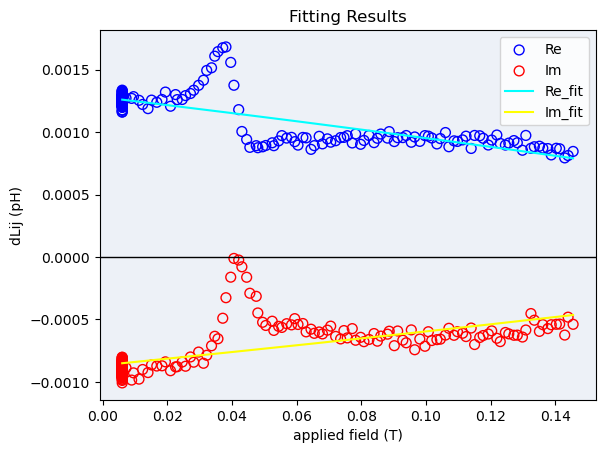


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.0102         0.0893         U        No
Ai                       -0.0127         0.0893         U        No
Ho                        2.0000         5.3336         T        No
dH                        0.2000         5.3336         T        No
re0                       0.0069         0.0229         U        No
im0                      -0.0067         0.0229         U        No
----------------------------------------------------------------------
Index= 3, freq.=6.528 GHz, Guide field.=0.03839695748092686


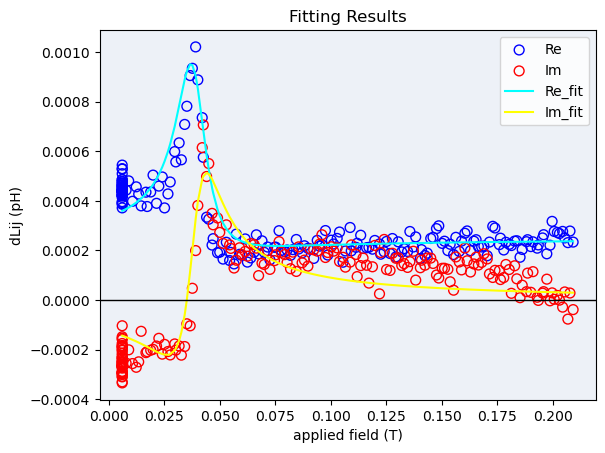


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.438e-06      2.434e-07         U        No
Ai                     5.486e-06      2.434e-07         U        No
Ho                        0.0387      4.452e-04         T        No
dH                        0.0082      4.452e-04         T        No
re0                    2.495e-04      6.818e-06         U        No
im0                   -3.333e-06      6.818e-06         U        No
----------------------------------------------------------------------
Index= 4, freq.=8.565 GHz, Guide field.=0.061635669516569846


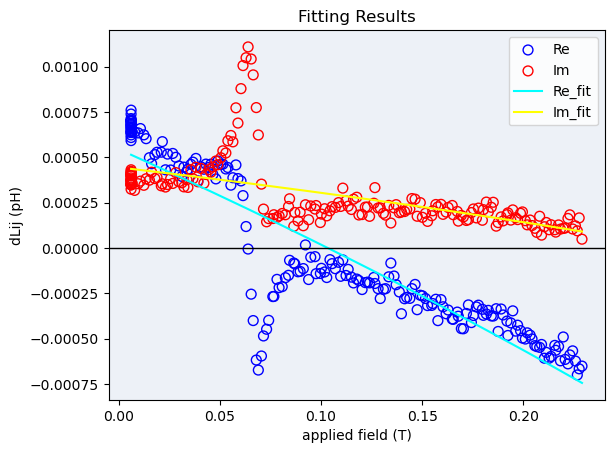


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                        0.0209         0.0383         U        No
Ai                        0.0012         0.0383         U        No
Ho                        2.0000         1.7365         T        No
dH                        0.2000         1.7365         T        No
re0                       0.0108         0.0101         U        No
im0                       0.0020         0.0101         U        No
----------------------------------------------------------------------
Index= 5, freq.=10.257 GHz, Guide field.=0.0850239363530002


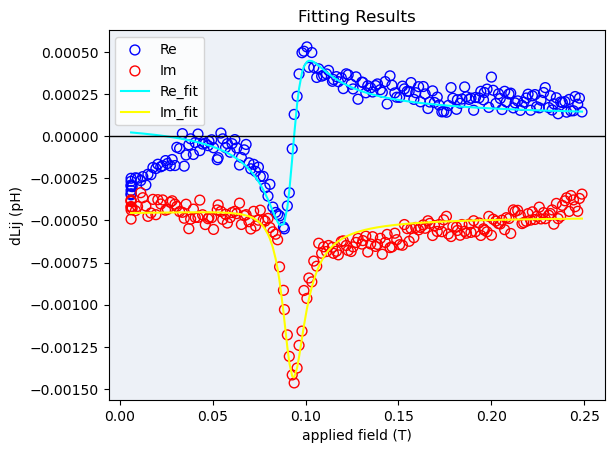


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.837e-06      2.515e-07         U        No
Ai                    -2.123e-06      2.515e-07         U        No
Ho                        0.0924      3.395e-04         T        No
dH                        0.0073      3.395e-04         T        No
re0                    1.030e-04      6.935e-06         U        No
im0                   -4.732e-04      6.935e-06         U        No
----------------------------------------------------------------------
Index= 6, freq.=11.722 GHz, Guide field.=0.10802121875991877


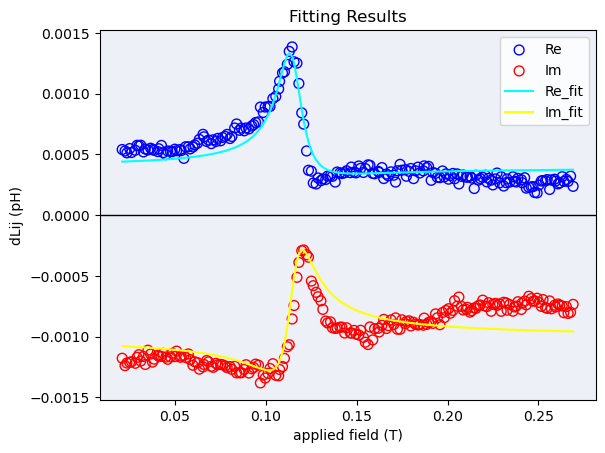


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.657e-06      3.706e-07         U        No
Ai                     7.274e-06      3.706e-07         U        No
Ho                        0.1150      4.925e-04         T        No
dH                        0.0082      4.925e-04         T        No
re0                    3.951e-04      9.580e-06         U        No
im0                      -0.0010      9.580e-06         U        No
----------------------------------------------------------------------
Index= 7, freq.=13.015 GHz, Guide field.=0.13026913083051972


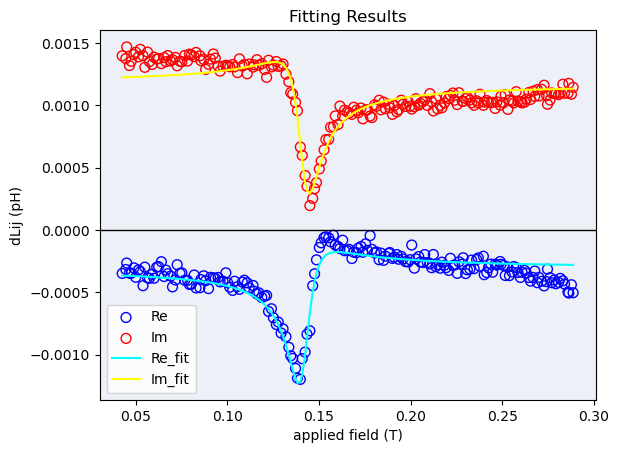


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.946e-06      2.186e-07         U        No
Ai                    -5.505e-06      2.186e-07         U        No
Ho                        0.1415      2.762e-04         T        No
dH                        0.0070      2.762e-04         T        No
re0                   -3.114e-04      6.205e-06         U        No
im0                       0.0012      6.205e-06         U        No
----------------------------------------------------------------------
Index= 8, freq.=14.181 GHz, Guide field.=0.1517829958828465


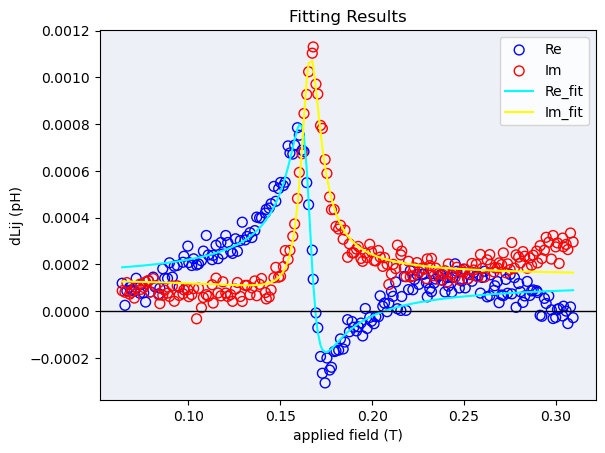


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -5.811e-06      1.530e-07         U        No
Ai                     2.363e-06      1.530e-07         U        No
Ho                        0.1652      2.098e-04         T        No
dH                        0.0064      2.098e-04         T        No
re0                    1.288e-04      4.618e-06         U        No
im0                    1.465e-04      4.618e-06         U        No
----------------------------------------------------------------------
Index= 9, freq.=15.249 GHz, Guide field.=0.1726111008644705


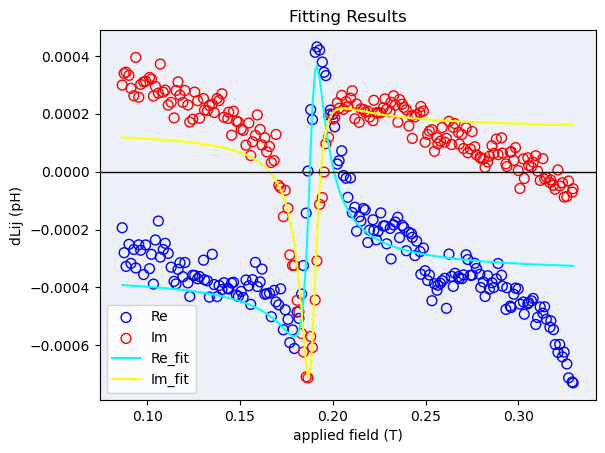


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.977e-06      2.602e-07         U        No
Ai                     2.550e-06      2.602e-07         U        No
Ho                        0.1885      3.756e-04         T        No
dH                        0.0051      3.756e-04         T        No
re0                   -3.543e-04      9.036e-06         U        No
im0                    1.447e-04      9.036e-06         U        No
----------------------------------------------------------------------
Index= 10, freq.=16.247 GHz, Guide field.=0.1929791867673999


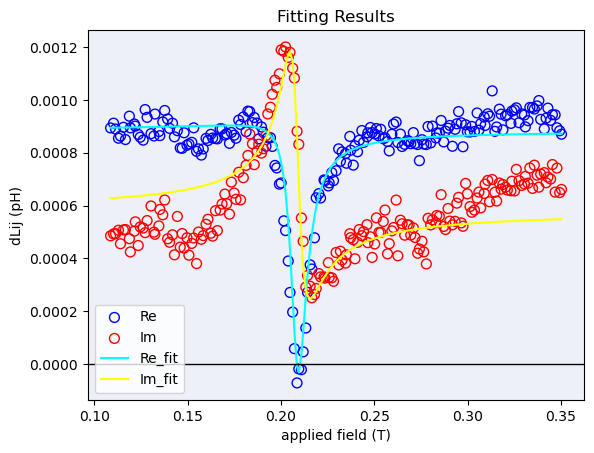


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.387e-06      1.923e-07         U        No
Ai                    -4.622e-06      1.923e-07         U        No
Ho                        0.2086      2.762e-04         T        No
dH                        0.0052      2.762e-04         T        No
re0                    8.835e-04      6.681e-06         U        No
im0                    5.811e-04      6.681e-06         U        No
----------------------------------------------------------------------
Index= 11, freq.=17.196 GHz, Guide field.=0.21310645268728257


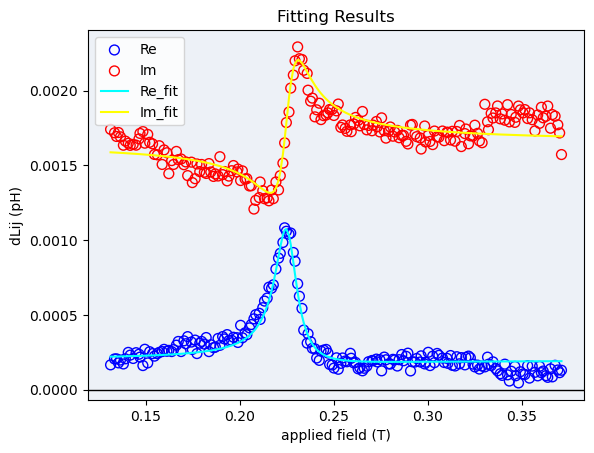


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.561e-06      1.881e-07         U        No
Ai                     6.174e-06      1.881e-07         U        No
Ho                        0.2256      2.771e-04         T        No
dH                        0.0072      2.771e-04         T        No
re0                    1.992e-04      5.505e-06         U        No
im0                       0.0017      5.505e-06         U        No
----------------------------------------------------------------------
Index= 12, freq.=18.118 GHz, Guide field.=0.23332596061060495


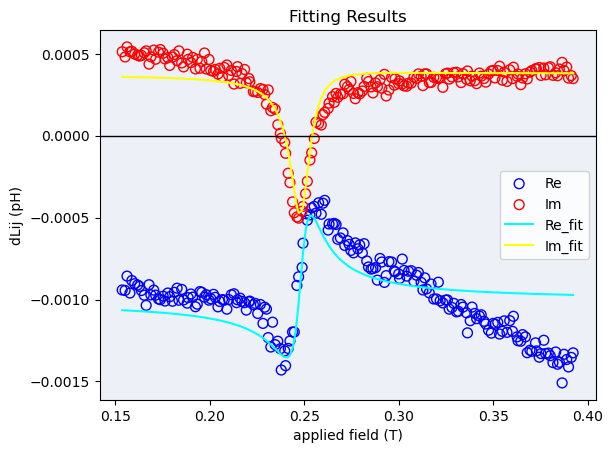


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.367e-06      3.404e-07         U        No
Ai                     1.127e-06      3.404e-07         U        No
Ho                        0.2484      5.202e-04         T        No
dH                        0.0063      5.202e-04         T        No
re0                      -0.0010      1.073e-05         U        No
im0                    3.756e-04      1.073e-05         U        No
----------------------------------------------------------------------
Index= 13, freq.=19.023 GHz, Guide field.=0.2537712026555847


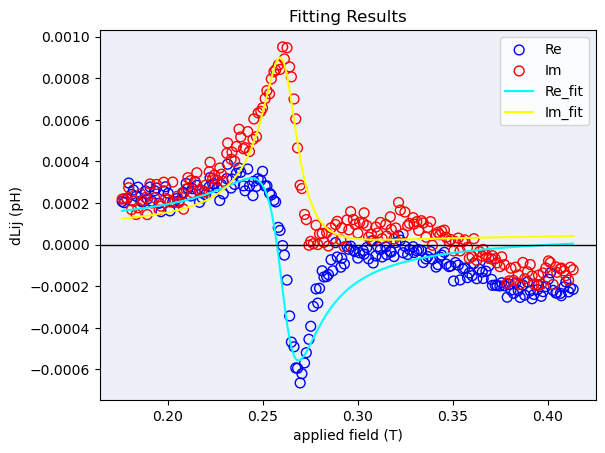


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -8.963e-06      4.307e-07         U        No
Ai                    -4.170e-06      4.307e-07         U        No
Ho                        0.2615      6.207e-04         T        No
dH                        0.0113      6.207e-04         T        No
re0                    6.598e-05      9.821e-06         U        No
im0                    6.441e-05      9.821e-06         U        No
----------------------------------------------------------------------
Index= 14, freq.=19.917 GHz, Guide field.=0.27451513756218415


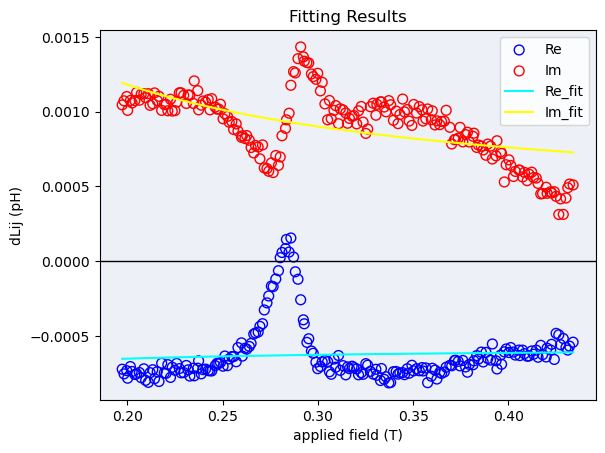


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.566e-05      1.692e-04         U        No
Ai                     1.679e-04      1.692e-04         U        No
Ho                     5.789e-18         0.1404         T        No
dH                     1.000e-04         0.1404         T        No
re0                   -5.741e-04      2.900e-04         U        No
im0                    3.412e-04      2.900e-04         U        No
----------------------------------------------------------------------
Index= 15, freq.=20.802 GHz, Guide field.=0.2955539304063386


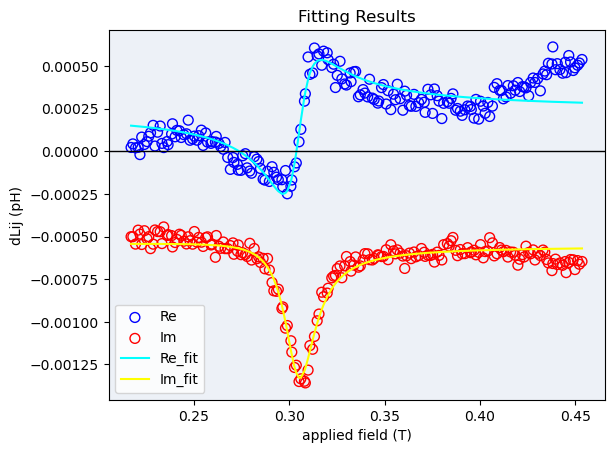


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     7.397e-06      2.426e-07         U        No
Ai                    -1.809e-06      2.426e-07         U        No
Ho                        0.3044      3.972e-04         T        No
dH                        0.0097      3.972e-04         T        No
re0                    2.357e-04      5.970e-06         U        No
im0                   -5.546e-04      5.970e-06         U        No
----------------------------------------------------------------------
Index= 16, freq.=21.674 GHz, Guide field.=0.31674481145618927


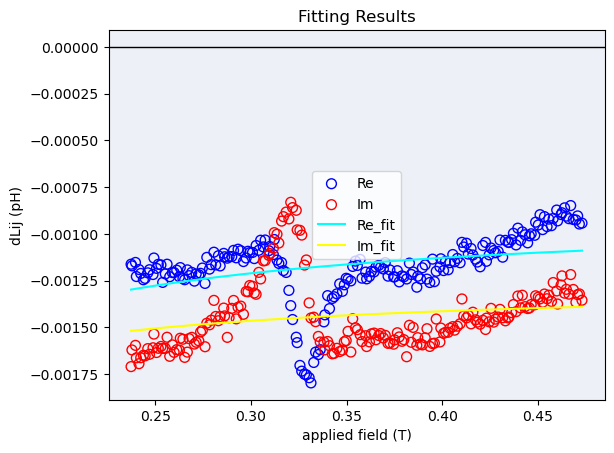


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -9.911e-05      2.299e-04         U        No
Ai                    -6.134e-05      2.299e-04         U        No
Ho                     1.442e-21         0.3194         T        No
dH                     1.000e-04         0.3194         T        No
re0                   -8.802e-04      3.433e-04         U        No
im0                      -0.0013      3.433e-04         U        No
----------------------------------------------------------------------
Index= 17, freq.=22.532 GHz, Guide field.=0.338016079189531


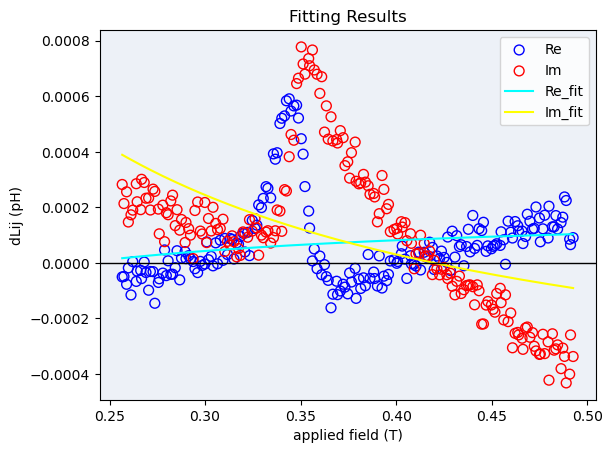


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.654e-05      2.995e-04         U        No
Ai                     2.571e-04      2.995e-04         U        No
Ho                     7.521e-24         0.1980         T        No
dH                     1.000e-04         0.1980         T        No
re0                    1.979e-04      4.211e-04         U        No
im0                   -6.124e-04      4.211e-04         U        No
----------------------------------------------------------------------
Index= 18, freq.=23.371 GHz, Guide field.=0.35919653890074654


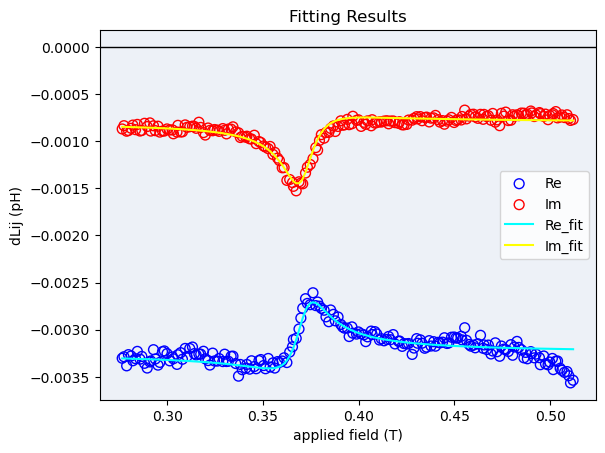


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.687e-06      2.189e-07         U        No
Ai                     3.642e-06      2.189e-07         U        No
Ho                        0.3708      4.035e-04         T        No
dH                        0.0096      4.035e-04         T        No
re0                      -0.0032      5.371e-06         U        No
im0                   -8.033e-04      5.371e-06         U        No
----------------------------------------------------------------------
Index= 19, freq.=24.185 GHz, Guide field.=0.38008501929684635


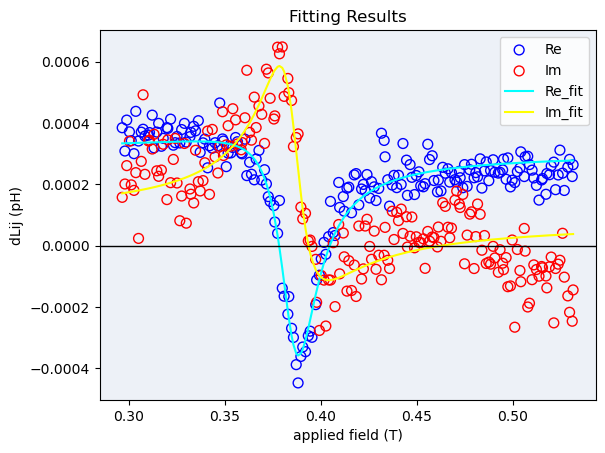


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -3.491e-06      3.032e-07         U        No
Ai                    -7.275e-06      3.032e-07         U        No
Ho                        0.3858      5.496e-04         T        No
dH                        0.0115      5.496e-04         T        No
re0                    3.057e-04      6.720e-06         U        No
im0                    8.563e-05      6.720e-06         U        No
----------------------------------------------------------------------
Index= 20, freq.=24.973 GHz, Guide field.=0.40060712578158286


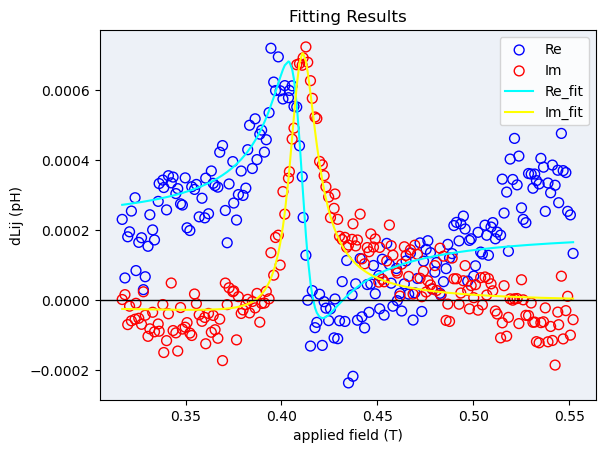


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -5.969e-06      2.620e-07         U        No
Ai                     1.852e-06      2.620e-07         U        No
Ho                        0.4098      4.658e-04         T        No
dH                        0.0085      4.658e-04         T        No
re0                    2.062e-04      6.909e-06         U        No
im0                   -1.147e-05      6.909e-06         U        No
----------------------------------------------------------------------
Index= 21, freq.=25.737 GHz, Guide field.=0.42077185425055386


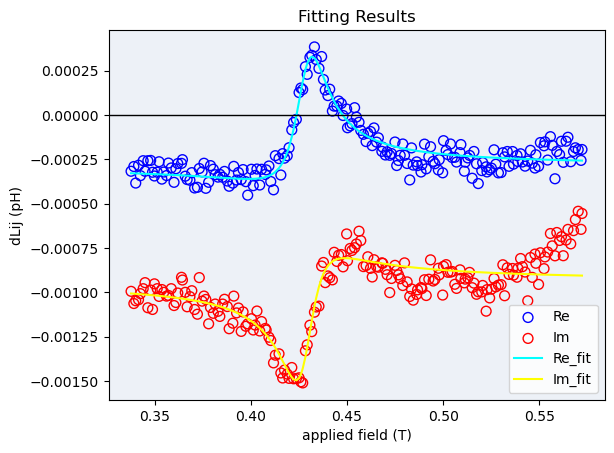


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.233e-06      2.626e-07         U        No
Ai                     5.501e-06      2.626e-07         U        No
Ho                        0.4284      4.874e-04         T        No
dH                        0.0101      4.874e-04         T        No
re0                   -2.892e-04      6.358e-06         U        No
im0                   -9.422e-04      6.358e-06         U        No
----------------------------------------------------------------------
Index= 22, freq.=26.481 GHz, Guide field.=0.44064905964446544


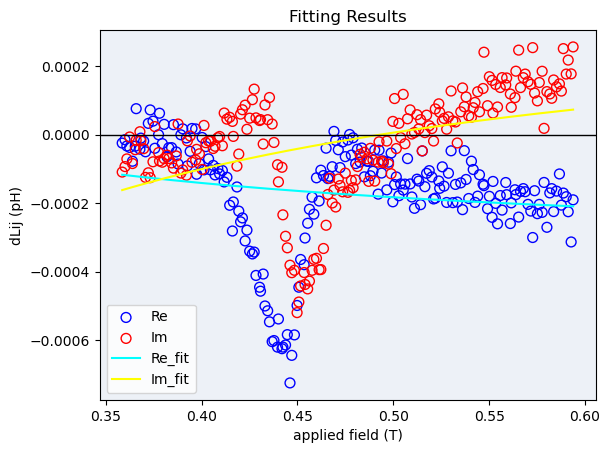


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     8.343e-05      5.166e-04         U        No
Ai                    -2.126e-04      5.166e-04         U        No
Ho                     3.483e-18         0.5129         T        No
dH                     1.000e-04         0.5129         T        No
re0                   -3.500e-04      5.602e-04         U        No
im0                    4.308e-04      5.602e-04         U        No
----------------------------------------------------------------------
Index= 23, freq.=27.209 GHz, Guide field.=0.4603170118341613


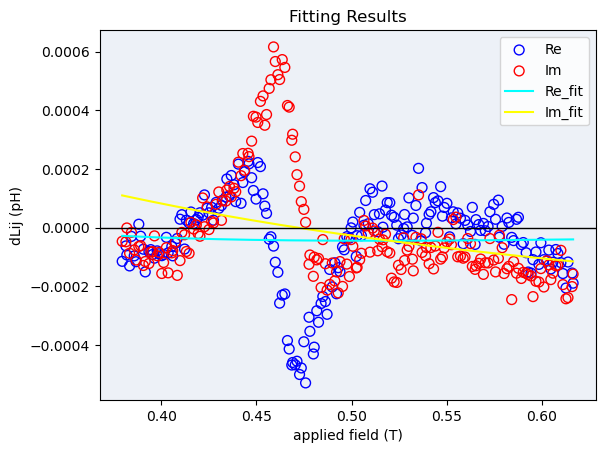


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.791e-04      8.137e-04         U        No
Ai                     1.943e-04      8.137e-04         U        No
Ho                     3.041e-15         0.8014         T        No
dH                        0.2000         0.8014         T        No
re0                    1.304e-04      7.754e-04         U        No
im0                   -4.855e-04      7.754e-04         U        No
----------------------------------------------------------------------
Index= 24, freq.=27.928 GHz, Guide field.=0.47994345624212165


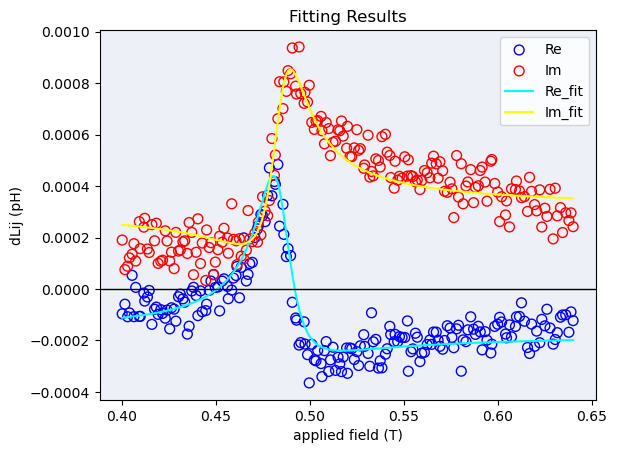


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.429e-06      2.447e-07         U        No
Ai                     5.981e-06      2.447e-07         U        No
Ho                        0.4843      4.532e-04         T        No
dH                        0.0109      4.532e-04         T        No
re0                   -1.731e-04      5.704e-06         U        No
im0                    3.123e-04      5.704e-06         U        No
----------------------------------------------------------------------
Index= 25, freq.=28.651 GHz, Guide field.=0.49987155412078654


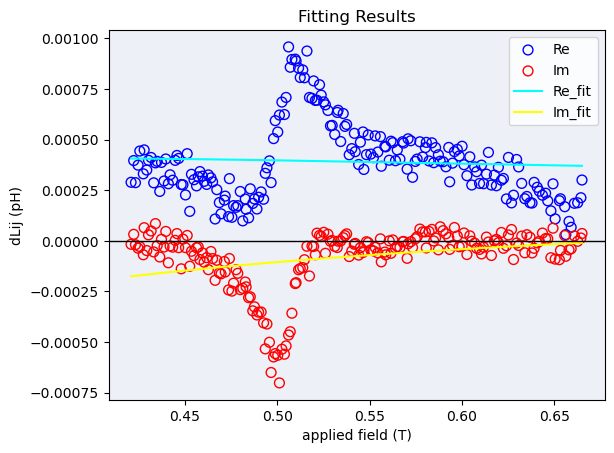


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.830e-04      9.939e-04         U        No
Ai                    -1.307e-04      9.939e-04         U        No
Ho                     3.319e-11         1.2399         T        No
dH                        0.2000         1.2399         T        No
re0                    1.724e-04      8.789e-04         U        No
im0                    2.464e-04      8.789e-04         U        No
----------------------------------------------------------------------
Index= 26, freq.=29.384 GHz, Guide field.=0.5202629880333156


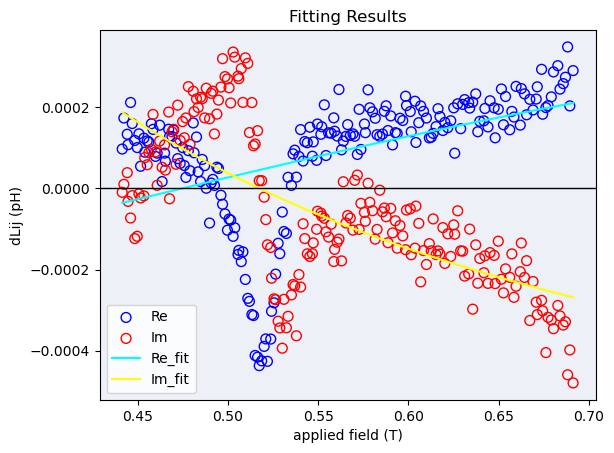


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.755e-04      8.637e-04         U        No
Ai                     2.614e-04      8.637e-04         U        No
Ho                     6.066e-16         0.3470         T        No
dH                        0.2000         0.3470         T        No
re0                       0.0010      7.361e-04         U        No
im0                   -8.785e-04      7.361e-04         U        No
----------------------------------------------------------------------
Index= 27, freq.=30.138 GHz, Guide field.=0.541426411166587


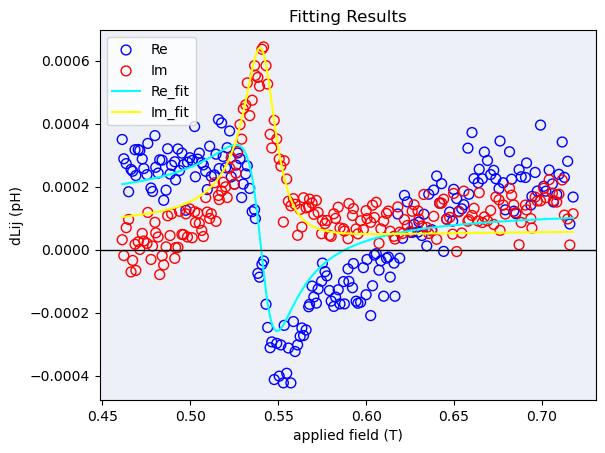


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.174e-06      3.464e-07         U        No
Ai                    -2.193e-06      3.464e-07         U        No
Ho                        0.5416      7.395e-04         T        No
dH                        0.0111      7.395e-04         T        No
re0                    1.364e-04      7.900e-06         U        No
im0                    6.673e-05      7.900e-06         U        No
----------------------------------------------------------------------
Index= 28, freq.=30.918 GHz, Guide field.=0.5635102822134708


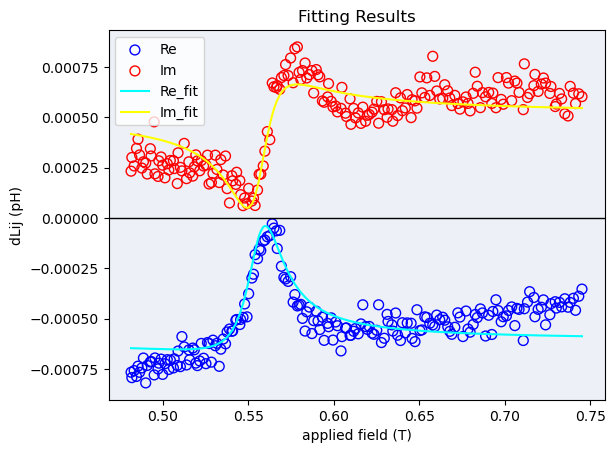


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     3.930e-06      3.553e-07         U        No
Ai                     6.688e-06      3.553e-07         U        No
Ho                        0.5565      7.216e-04         T        No
dH                        0.0126      7.216e-04         T        No
re0                   -6.111e-04      7.403e-06         U        No
im0                    5.115e-04      7.403e-06         U        No
----------------------------------------------------------------------
Index= 29, freq.=31.727 GHz, Guide field.=0.5866098871608918


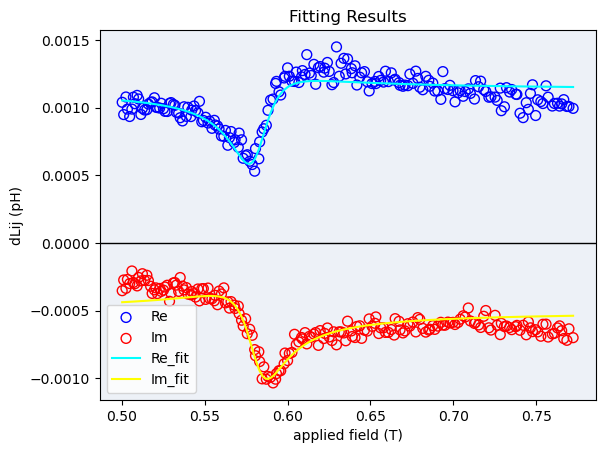


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     5.192e-06      3.289e-07         U        No
Ai                    -6.303e-06      3.289e-07         U        No
Ho                        0.5815      6.686e-04         T        No
dH                        0.0133      6.686e-04         T        No
re0                       0.0011      6.542e-06         U        No
im0                   -5.039e-04      6.542e-06         U        No
----------------------------------------------------------------------
Index= 30, freq.=32.569 GHz, Guide field.=0.6108515042418157


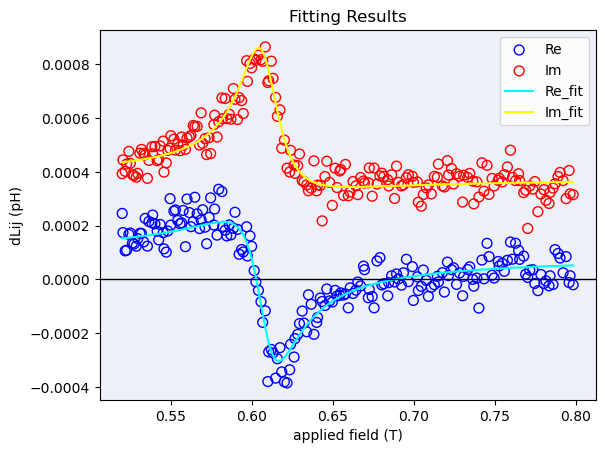


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -6.512e-06      2.269e-07         U        No
Ai                    -3.904e-06      2.269e-07         U        No
Ho                        0.6083      5.459e-04         T        No
dH                        0.0147      5.459e-04         T        No
re0                    8.807e-05      4.181e-06         U        No
im0                    3.804e-04      4.181e-06         U        No
----------------------------------------------------------------------
Index= 31, freq.=33.441 GHz, Guide field.=0.6361603254655244


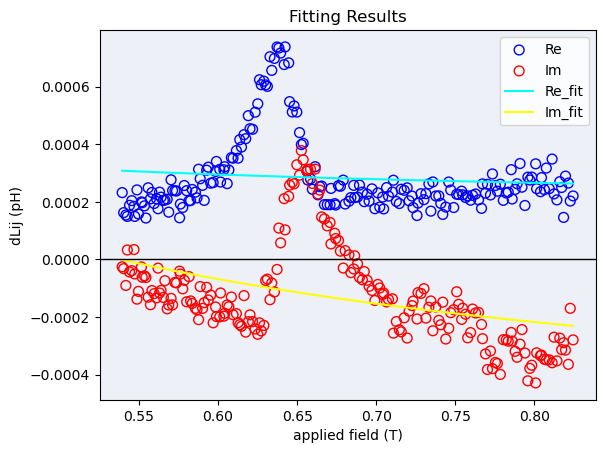


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.931e-05      9.932e-04         U        No
Ai                     3.578e-04      9.932e-04         U        No
Ho                     1.005e-15         0.8942         T        No
dH                     1.000e-04         0.8942         T        No
re0                    1.792e-04      7.475e-04         U        No
im0                   -6.645e-04      7.475e-04         U        No
----------------------------------------------------------------------
Index= 32, freq.=34.337 GHz, Guide field.=0.6623698066048522


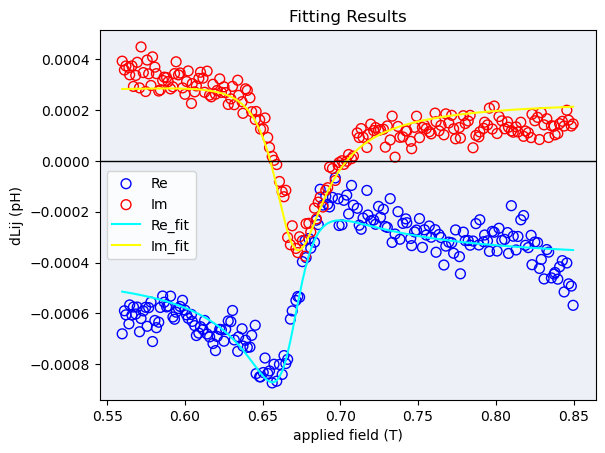


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     1.097e-05      3.698e-07         U        No
Ai                    -5.611e-06      3.698e-07         U        No
Ho                        0.6682      7.098e-04         T        No
dH                        0.0194      7.098e-04         T        No
re0                   -4.072e-04      5.595e-06         U        No
im0                    2.495e-04      5.595e-06         U        No
----------------------------------------------------------------------
Index= 33, freq.=35.247 GHz, Guide field.=0.6891889960138768


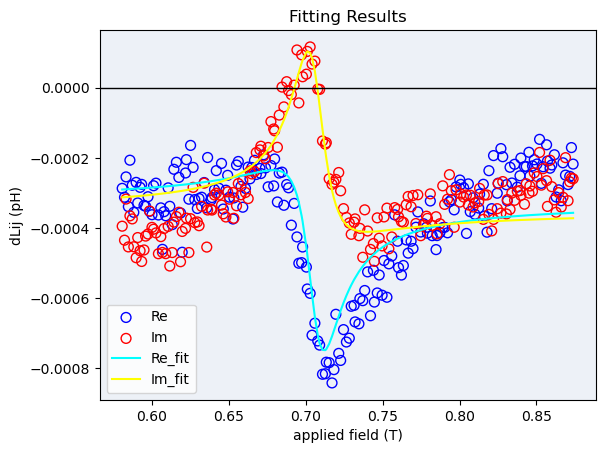


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -4.918e-06      3.596e-07         U        No
Ai                    -4.185e-06      3.596e-07         U        No
Ho                        0.7061      9.039e-04         T        No
dH                        0.0125      9.039e-04         T        No
re0                   -3.259e-04      6.880e-06         U        No
im0                   -3.497e-04      6.880e-06         U        No
----------------------------------------------------------------------
Index= 34, freq.=36.165 GHz, Guide field.=0.7164371537116478


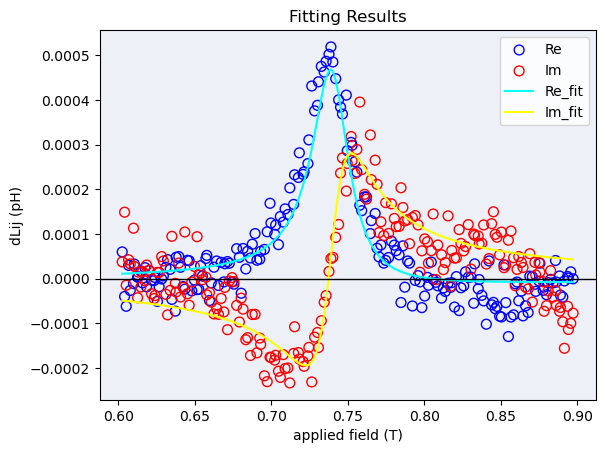


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.298e-06      2.603e-07         U        No
Ai                     6.844e-06      2.603e-07         U        No
Ho                        0.7401      6.978e-04         T        No
dH                        0.0146      6.978e-04         T        No
re0                   -3.465e-06      4.538e-06         U        No
im0                   -9.632e-07      4.538e-06         U        No
----------------------------------------------------------------------
Index= 35, freq.=37.077 GHz, Guide field.=0.7436888819609766


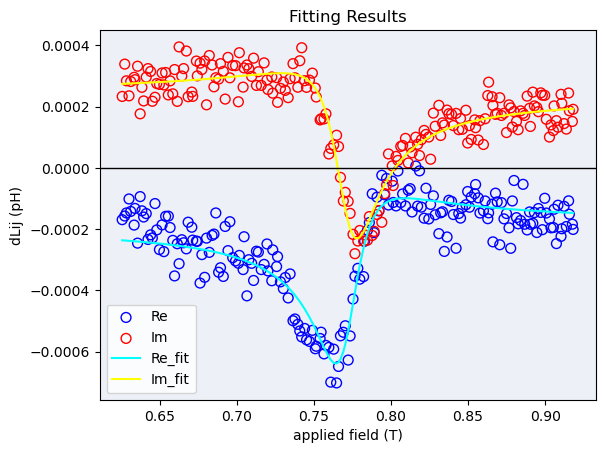


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     6.612e-06      2.792e-07         U        No
Ai                    -6.030e-06      2.792e-07         U        No
Ho                        0.7715      6.509e-04         T        No
dH                        0.0166      6.509e-04         T        No
re0                   -1.870e-04      4.550e-06         U        No
im0                    2.389e-04      4.550e-06         U        No
----------------------------------------------------------------------
Index= 36, freq.=37.972 GHz, Guide field.=0.7705992229665375


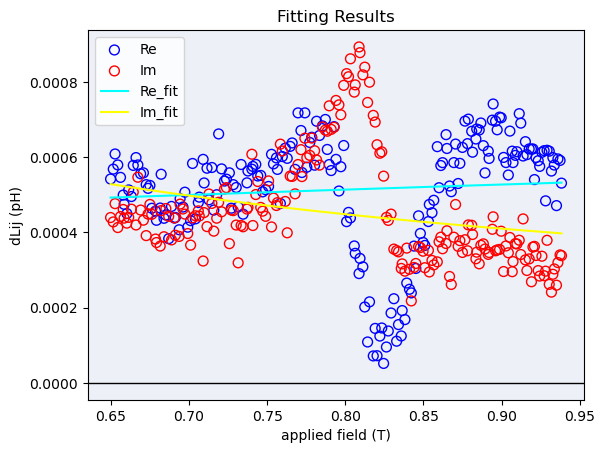


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -2.225e-04         0.0017         U        No
Ai                     2.148e-04         0.0017         U        No
Ho                     8.237e-20         2.2459         T        No
dH                        0.2000         2.2459         T        No
re0                    7.125e-04         0.0011         U        No
im0                    1.304e-04         0.0011         U        No
----------------------------------------------------------------------
Index= 37, freq.=38.837 GHz, Guide field.=0.7967562058204243


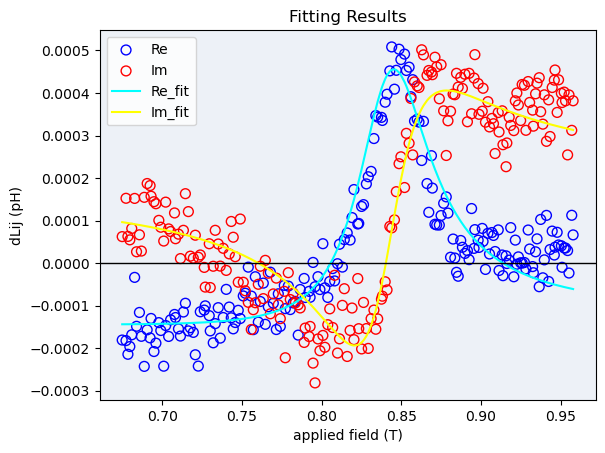


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     4.844e-06      4.964e-07         U        No
Ai                     1.583e-05      4.964e-07         U        No
Ho                        0.8412      9.508e-04         T        No
dH                        0.0276      9.508e-04         T        No
re0                   -1.307e-04      6.107e-06         U        No
im0                    1.938e-04      6.107e-06         U        No
----------------------------------------------------------------------
Index= 38, freq.=39.667 GHz, Guide field.=0.8219853396988794


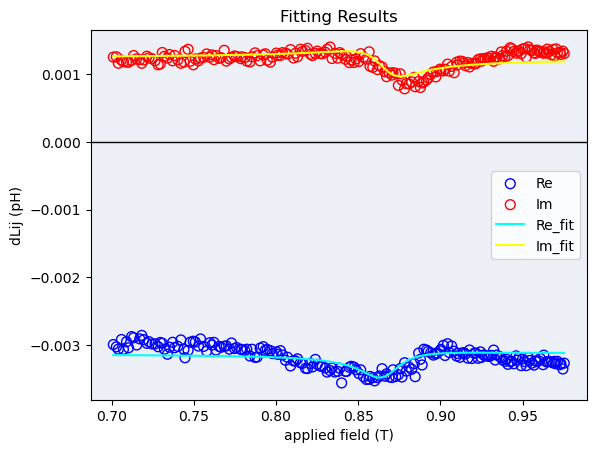


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                     2.412e-06      5.037e-07         U        No
Ai                    -4.849e-06      5.037e-07         U        No
Ho                        0.8664         0.0017         T        No
dH                        0.0147         0.0017         T        No
re0                      -0.0031      9.213e-06         U        No
im0                       0.0012      9.213e-06         U        No
----------------------------------------------------------------------
Index= 39, freq.=40.454 GHz, Guide field.=0.8460199013877507


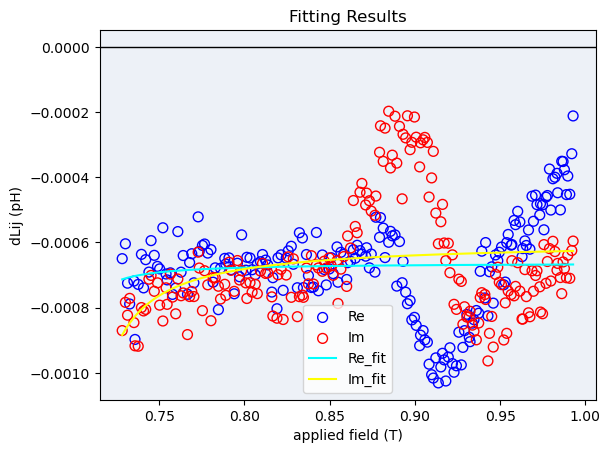


Fit Results
----------------------------------------------------------------------
Parameter                  Value        ± Error      Unit     Fixed
----------------------------------------------------------------------
Ar                    -1.484e-06      6.636e-06         U        No
Ai                    -8.581e-06      6.636e-06         U        No
Ho                        0.6984         0.0257         T        No
dH                     1.000e-04         0.0257         T        No
re0                   -6.626e-04      3.399e-05         U        No
im0                   -5.970e-04      3.399e-05         U        No
----------------------------------------------------------------------


In [33]:
 est_gamma = 28.8 #GHz/T
 est_hx = 1500.0/1000 #T
 est_hy = -5/1000 #T

 for i in range(len(ansy1.freqs)):
     f_index = i
     freq_i = ansy1.freqs[f_index]
     H_guide = res_func.inverse_kittel_general(freq_i, est_gamma, est_hx, est_hy)

     print(f"Index= {i}, freq.={freq_i} GHz, Guide field.={H_guide}")
     ini_vals = [1, 1, H_guide, 0.028, 0, 0] #Ar, Ai, Ho, dH, re0, im0


     H_min, H_max = H_guide-0.5, H_guide+0.5 #T
     h_array = ansy1.get_field(freq_i)
     y_array_re, y_array_im = ansy1.d_S("21R", freq_i), ansy1.d_S("21I", freq_i)

     model = models.ComplexLorentzian_field()
     fitter = fits.ComplexFitter( ini_vals, H_min, H_max,
                                 h_array, y_array_re , y_array_im, model)
     fitter.fix(Ho=H_center, dH=0.005, re0=0, im0=0) # Parameters to be fixed, empty otherwise
     opt_p0 = fitter.simplex_wpm(method='Nelder-Mead')#'Powell'

     new_p0 = np.array(list(opt_p0.values()), dtype=float)
     fitter.update_p0(new_p0)



     params, cov = fitter.fit(simplex_b=False)
     fitter.plot_fit()
     fitter.summary()
     fit_dict = fitter.export_fit_dict()
     fits_storage.save(index=f_index, val=float(freq_i), fit_dict=fit_dict)

In [ ]:
#Realoading parameters

In [ ]:
data_L_fits = fits_storage.load_fit_results(newFile, group="Lorentzian fitting")

In [ ]:
fits_storage.plot_fit_parameters_subplots(
    data_L_fits,
    x_axis="index",
    params=["dH", "Ho"],
    x_label= "index"#"μ₀H (T)"
)

In [ ]:
cut_data_L_fits = fits_storage.slice_dict(data_L_fits, 1, 38)

In [ ]:
#Plotting of fitted parameters

In [ ]:
fits_storage.plot_fit_parameters_subplots(
    cut_data_L_fits,
    x_axis="freq",
    params=["dH", "Ho"],
    x_label= "frequency"#"(GHz)"
)